In [1]:
import matplotlib.pyplot as plt
from pygam import (
    f, ExpectileGAM, GAM, LinearGAM, LogisticGAM, PoissonGAM, s, te)
from pygam.datasets import (
    chicago, default, faithful, mcycle, toy_interaction, wage)
from mpl_toolkits import mplot3d

%matplotlib inline

In [2]:
GAM(s(0, n_splines=200) + te(3, 1) + s(2), 
    distribution='poisson', 
    link='log')

GAM(callbacks=['deviance', 'diffs'], distribution='poisson', 
   fit_intercept=True, link='log', max_iter=100, 
   terms=s(0) + te(3, 1) + s(2), tol=0.0001, verbose=False)

In [3]:
# GAM(..., intercept=False)  # to exclude intercept

### Shortcuts:
```

Function      | link     | distribution
-----------------------------------------
LinearGAM()   | identity | normal 
LogisticGAM() | logit    | binomial
PoissonGAM()  | log      | poisson
GammaGAM()    | log      | gamma
InvGauss      | log      | inv guassian
```

In [4]:
X, y = chicago(return_X_y=True)
gam = PoissonGAM(s(0, n_splines=200) + te(1, 3) + s(2)).fit(X, y)

/usr/local/lib/python3.6/site-packages/scipy/linalg/basic.py:1321: RuntimeWarning: internal gelsd driver lwork query error, required iwork dimension not returned. This is likely the result of LAPACK bug 0038, fixed in LAPACK 3.2.2 (released July 21, 2010). Falling back to 'gelss' driver.
  x, resids, rank, s = lstsq(a, b, cond=cond, check_finite=False)


In [5]:
plt.ion()
plt.rcParams['figure.figsize'] = (12, 8)

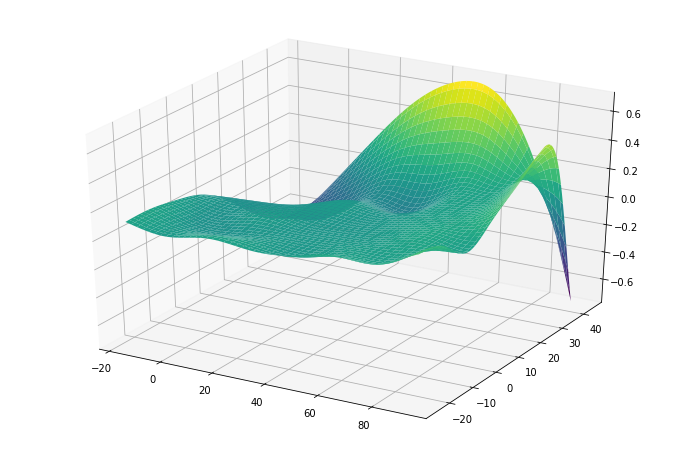

In [6]:
XX = gam.generate_X_grid(term=1, meshgrid=True)
Z = gam.partial_dependence(term=1, X=XX, meshgrid=True)

ax = plt.axes(projection='3d')
ax.plot_surface(XX[0], XX[1], Z, cmap='viridis');

In [7]:
X, y = toy_interaction(return_X_y=True)

gam = LinearGAM(s(0, by=1)).fit(X, y)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     20.8492
Link Function:                     IdentityLink Log Likelihood:                              -2318518.4584
Number of Samples:                        50000 AIC:                                          4637080.6153
                                                AICc:                                         4637080.6353
                                                GCV:                                                  0.01
                                                Scale:                                                0.01
                                                Pseudo R-Squared:                                   0.9976
Feature Function                  Lam

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:4: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  after removing the cwd from sys.path.


In [8]:
X, y = wage(return_X_y=True)

gam = LinearGAM(s(0) + s(1) + f(2))
gam.gridsearch(X, y)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.2602
Link Function:                     IdentityLink Log Likelihood:                                -24116.7451
Number of Samples:                         3000 AIC:                                            48274.0107
                                                AICc:                                           48274.2999
                                                GCV:                                             1250.3656
                                                Scale:                                           1235.9245
                                                Pseudo R-Squared:                                   0.2945
Feature Function                  Lam


/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:5: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  """


<Figure size 864x576 with 0 Axes>

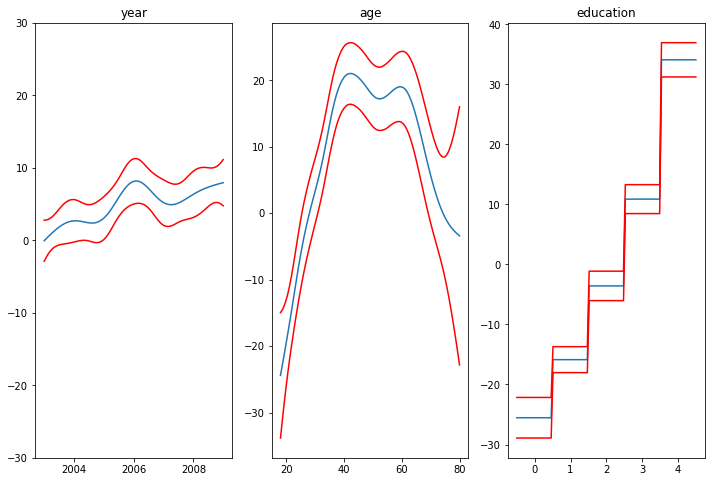

In [9]:
plt.rcParams['figure.figsize'] = (12, 8)
plt.figure()
fig, axs = plt.subplots(1, 3)

titles = ['year', 'age', 'education']
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], 
            gam.partial_dependence(term=i, X=XX, width=0.95)[1], 
            c='r')
    if i == 0:
        ax.set_ylim(-30, 30)
    ax.set_title(titles[i]);

In [11]:
X, y = mcycle(return_X_y=True)

In [12]:
gam = LinearGAM(n_splines=30).gridsearch(X, y)
XX = gam.generate_X_grid(term=0, n=500)

100% |########################################################################|


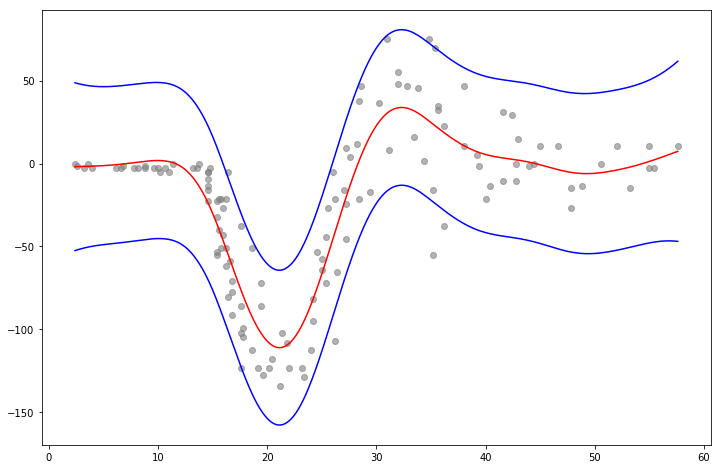

In [20]:
plt.figure(figsize=(12, 8))
plt.plot(XX, gam.predict(XX), 'r-')
plt.plot(XX, gam.prediction_intervals(XX, width=0.95), color='b')
plt.scatter(X, y, facecolor='grey', alpha=0.6);

100% |########################################################################|
100% |########################################################################|
100% |########################################################################|
100% |########################################################################|


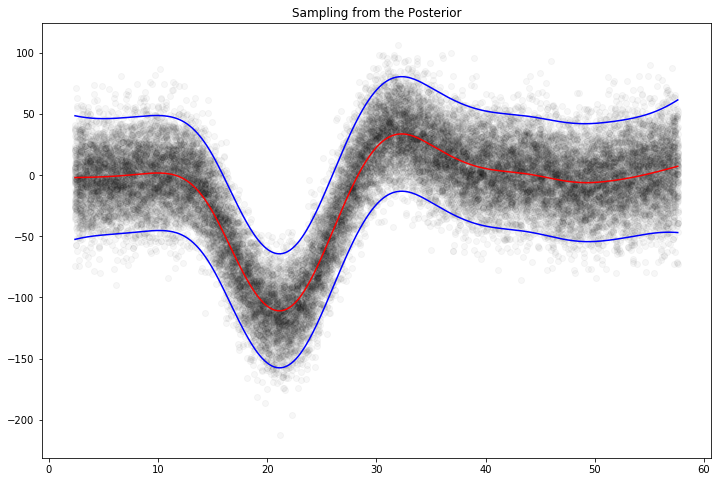

In [24]:
plt.figure(figsize=(12, 8))
for response in gam.sample(X, y, quantity='y', n_draws=50, sample_at_X=XX):
    plt.scatter(XX, response, alpha=0.03, color='k')
plt.plot(XX, gam.predict(XX), 'r-')
plt.plot(XX, gam.prediction_intervals(XX, width=0.95), color='b')
plt.title('Sampling from the Posterior');

In [26]:
X, y = default(return_X_y=True)
gam = LogisticGAM(f(0) + s(1) + s(2)).gridsearch(X, y)

100% |########################################################################|


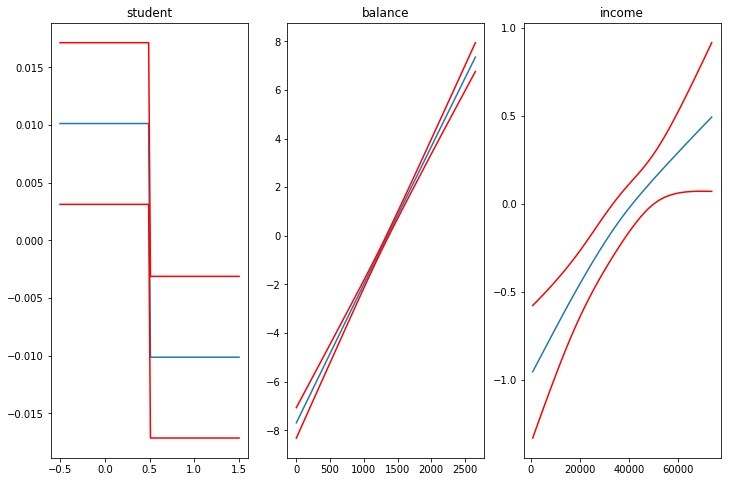

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(12, 8))
titles = ['student', 'balance', 'income']

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    pdep, conf = gam.partial_dependence(term=i, width=0.95)
    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], conf, c='r')
    ax.set_title(titles[i])

In [30]:
gam.accuracy(X, y)

0.9739

In [31]:
gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                      3.8047
Link Function:                        LogitLink Log Likelihood:                                   -788.877
Number of Samples:                        10000 AIC:                                             1585.3634
                                                AICc:                                             1585.369
                                                UBRE:                                               2.1588
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.4598
Feature Function                  Lam

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  """Entry point for launching an IPython kernel.


In [33]:
X, y = faithful(return_X_y=True)
gam = PoissonGAM().gridsearch(X, y)

100% |########################################################################|


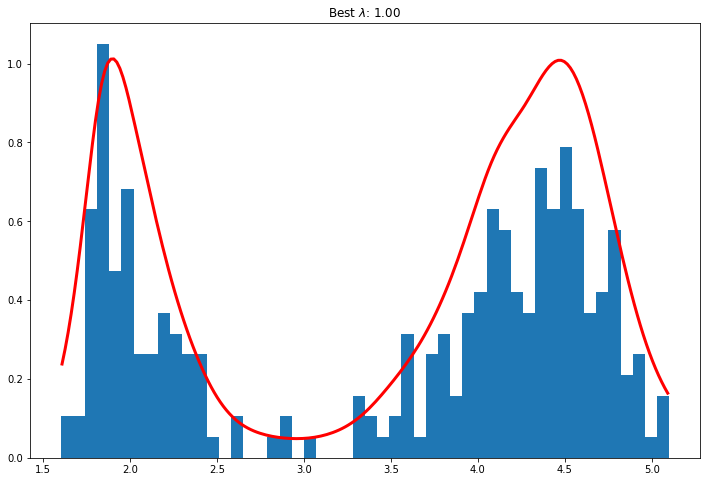

In [47]:
plt.figure(figsize=(12, 8))
plt.hist(faithful(return_X_y=False)['eruptions'], density=True, bins=50);
plt.plot(X, gam.predict(X) / 3, color='r', lw=3)
plt.title(r'Best $\lambda$: %.2f' % gam.lam[0][0]);

# Expectiles

In [2]:
X, y = mcycle(return_X_y=True)
gam50 = ExpectileGAM(expectile=0.5).gridsearch(X, y)
lmbda = gam50.lam
gam95 = ExpectileGAM(expectile=0.95, lam=lmbda).fit(X, y)
gam75 = ExpectileGAM(expectile=0.75, lam=lmbda).fit(X, y)
gam25 = ExpectileGAM(expectile=0.25, lam=lmbda).fit(X, y)
gam05 = ExpectileGAM(expectile=0.05, lam=lmbda).fit(X, y)

/usr/local/lib/python3.6/site-packages/scipy/linalg/basic.py:1321: RuntimeWarning: internal gelsd driver lwork query error, required iwork dimension not returned. This is likely the result of LAPACK bug 0038, fixed in LAPACK 3.2.2 (released July 21, 2010). Falling back to 'gelss' driver.
  x, resids, rank, s = lstsq(a, b, cond=cond, check_finite=False)
100% |########################################################################|


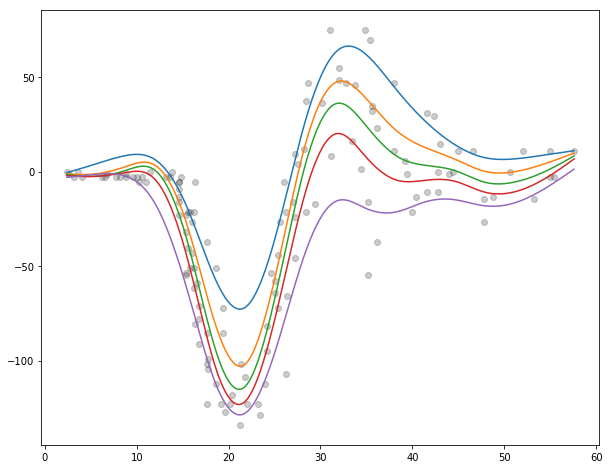

In [4]:
plt.figure(figsize=(10, 8))
XX = gam50.generate_X_grid(term=0, n=500)
plt.scatter(X, y, c='k', alpha=0.2)
plt.plot(XX, gam95.predict(XX), label='0.95')
plt.plot(XX, gam75.predict(XX), label='0.75')
plt.plot(XX, gam50.predict(XX), label='0.50')
plt.plot(XX, gam25.predict(XX), label='0.25')
plt.plot(XX, gam05.predict(XX), label='0.05');